# Machine Learning Project: Aly Mabrouk - Amirali Tamizi Horzadeh - Saeed AlShehhi - Ahmed AlSayegh

# E-Commerce Recommendation Engine 

This notebook builds a **personalized recommendation engine** using the **RetailRocket dataset**.  
We will:  
- Load and balance the dataset  
- Build a simple **ML recommendation model**  
- Evaluate using **real recommender metrics** (Precision@K, Recall@K)

Libraries used: 
- NumPy
- Pandas
- MatplotLib
- Seaborn

## Information About Data

### Context
The dataset consists of three files: a file with behaviour data (events.csv), a file with item properties (item_properties.сsv) and a file, which describes category tree (category_tree.сsv). The data has been collected from a real-world ecommerce website. It is raw data, i.e. without any content transformations, however, all values are hashed due to confidential issues. The purpose of publishing is to motivate researches in the field of recommender systems with implicit feedback.

### Content
The behaviour data, i.e. events like clicks, add to carts, transactions, represent interactions that were collected over a period of 4.5 months. A visitor can make three types of events, namely “view”, “addtocart” or “transaction”. In total there are 2 756 101 events including 2 664 312 views, 69 332 add to carts and 22 457 transactions produced by 1 407 580 unique visitors. For about 90% of events corresponding properties can be found in the “item_properties.csv” file. 

The file with item properties (item_properties.csv) includes 20 275 902 rows, i.e. different properties, describing 417 053 unique items. File is divided into 2 files due to file size limitations. Since the property of an item can vary in time (e.g., price changes over time), every row in the file has corresponding timestamp. In other words, the file consists of concatenated snapshots for every week in the file with the behaviour data

# Phase 1: Load relevant files

## Phase 1.1: Import libraries & tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

import ipywidgets as widgets
from IPython.display import display

sns.set(style="whitegrid")

## Phase 1.2: Load data

In [2]:
# Creating a Random seed for reproducibility
np.random.seed(42)

In [3]:
# Load datasets
data = pd.read_csv("./events.csv")
data.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


## Phase 1.3: Evaluate Data

In [4]:
print("Raw data shape:", data.shape)
print(data.head())
print(data.dtypes)

Raw data shape: (2756101, 5)
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object


# Phase 2: Data processing

## Phase 2.1: Cleaning Data

In [5]:
required_cols = ["timestamp", "visitorid", "event", "itemid"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"Missing required columns in data: {missing}")

# Drop rows with missing key columns
data = data.dropna(subset=["visitorid", "itemid", "event", "timestamp"])

# Normalize event names to lowercase for consistency
data["event"] = data["event"].astype(str).str.lower()

data.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [6]:
# Convert timestamp to datetime
# NOTE: Many e-commerce datasets use Unix time in milliseconds.
# If your timestamp is seconds, change unit="s".
data["event_time"] = pd.to_datetime(data["timestamp"], unit="ms", errors="coerce")
data = data.dropna(subset=["event_time"])
data.head()

,timestamp,visitorid,event,itemid,transactionid,event_time
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106


In [7]:
# Drop exact duplicate events if they exist
data = data.drop_duplicates(
    subset=["visitorid", "itemid", "event_time", "event"],
    keep="last"
)

In [8]:
# Define binary label:
#   1 for transaction or add-to-cart
#   0 for everything else (e.g., view)
positive_events = ["transaction", "addtocart"]
data["rating"] = data["event"].isin(positive_events).astype(int)

print("`` After cleaning:")
print("  Rows:", len(data))
print("  Unique visitors:", data["visitorid"].nunique())
print("  Unique items:", data["itemid"].nunique())
print("  Raw positive rate:", data["rating"].mean())
data.head()

`` After cleaning:
  Rows: 2755641
  Unique visitors: 1407580
  Unique items: 235061
  Raw positive rate: 0.03317667286849049


,timestamp,visitorid,event,itemid,transactionid,event_time,rating
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,0
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,0
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,0
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,0
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,0


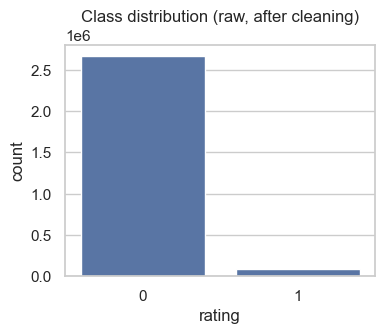

In [9]:
plt.figure(figsize=(4, 3))
sns.countplot(x="rating", data=data)
plt.title("Class distribution (raw, after cleaning)")
plt.show()

## Phase 2.2: Filter Ultra-Cold Users and Items

In [10]:
MIN_USER_INTERACTIONS = 3
MIN_ITEM_INTERACTIONS = 3

visitor_counts = data["visitorid"].value_counts()
active_visitors = visitor_counts[visitor_counts >= MIN_USER_INTERACTIONS].index
data = data[data["visitorid"].isin(active_visitors)]

item_counts = data["itemid"].value_counts()
popular_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
data = data[data["itemid"].isin(popular_items)]

print("After filtering cold visitors/items:")
print("  Rows:", len(data))
print("  Active visitors:", data["visitorid"].nunique())
print("  Popular items:", data["itemid"].nunique())
print("  Positive rate:", data["rating"].mean())

After filtering cold visitors/items:
  Rows: 1259369
  Active visitors: 197471
  Popular items: 70960
  Positive rate: 0.06397410131581768


## Phase 2.3: Analyze Visitor and Item Statistics

In [11]:
# Visitor-level stats
visitor_stats = (
    data.groupby("visitorid")["rating"]
    .agg(visitor_total_interactions="count", visitor_total_positives="sum")
    .reset_index()
)
visitor_stats["visitor_conversion_rate"] = (
    visitor_stats["visitor_total_positives"] / visitor_stats["visitor_total_interactions"]
)

In [12]:
# Item-level stats
item_stats = (
    data.groupby("itemid")["rating"]
    .agg(item_total_interactions="count", item_total_positives="sum")
    .reset_index()
)
item_stats["item_conversion_rate"] = (
    item_stats["item_total_positives"] / item_stats["item_total_interactions"]
)

In [13]:
# Merge them in mainly for EDA (we'll still use only IDs for the model here,
# but we could extend X to include these features later with a ColumnTransformer)
data = data.merge(visitor_stats, on="visitorid", how="left")
data = data.merge(item_stats, on="itemid", how="left")

print("Data shape after stats merge:", data.shape)

Data shape after stats merge: (1259369, 13)


In [14]:
pos = data[data["rating"] == 1].copy()
neg = data[data["rating"] == 0].copy()

print("Total positives:", len(pos))
print("Total negatives:", len(neg))
print(f'Percentage of positive interactions: {len(pos) * 100 / (len(pos) + len(neg)):.2f}%')

Total positives: 80567
Total negatives: 1178802
Percentage of positive interactions: 6.40%


## Phase 2.4 Preprocessing the data

In [15]:
NEG_PER_POS = 5  # tune this (e.g., 3–10)

neg_samples = []

In [16]:
for visitor_id, visitor_pos in pos.groupby("visitorid"):
    visitor_neg = neg[neg["visitorid"] == visitor_id]
    if len(visitor_neg) == 0:
        continue
    n_to_sample = min(len(visitor_neg), len(visitor_pos) * NEG_PER_POS)
    neg_samples.append(visitor_neg.sample(n_to_sample, random_state=42))

if len(neg_samples) > 0:
    neg_sampled = pd.concat(neg_samples, axis=0)
else:
    neg_sampled = neg.iloc[0:0]  # empty fallback

In [17]:
balanced = (
    pd.concat([pos, neg_sampled])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Balanced shape:", balanced.shape)
print("Balanced positive rate:", balanced["rating"].mean())

Balanced shape: (296807, 13)
Balanced positive rate: 0.27144575431172446


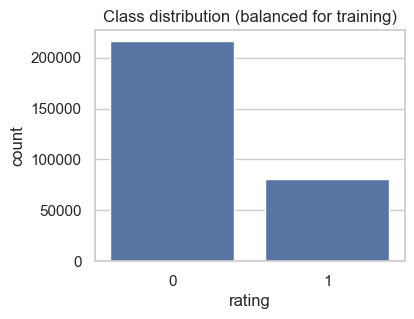

In [18]:
plt.figure(figsize=(4, 3))
sns.countplot(x="rating", data=balanced)
plt.title("Class distribution (balanced for training)")
plt.show()

## Phase 2.5: Encode visitor & item IDs to X, y

In [19]:
visitor_cat = balanced["visitorid"].astype("category")
item_cat   = balanced["itemid"].astype("category")

user_ids = visitor_cat.cat.codes.values   # encoded visitors
item_ids = item_cat.cat.codes.values      # encoded items
ratings  = balanced["rating"].values

num_users = len(np.unique(user_ids))
num_items = len(np.unique(item_ids))

X = np.vstack([user_ids, item_ids]).T  # shape (n_samples, 2)
y = ratings

print("Encoded users (visitors):", num_users, "| Encoded items:", num_items)
print("X shape:", X.shape, "| y positives:", y.sum(), "/", len(y))

Encoded users (visitors): 29257 | Encoded items: 38229
X shape: (296807, 2) | y positives: 80567 / 296807


In [20]:
# Store mappings if needed later
idx_to_visitor = dict(enumerate(visitor_cat.cat.categories))
idx_to_item    = dict(enumerate(item_cat.cat.categories))

# Phase 3: Machine Learning Implementation

## Phase 3.1: Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train size: (237445, 2) Test size: (59362, 2)
Train positive rate: 0.27144391332729684
Test positive rate: 0.27145311815639633


## Phase 3.2: Classic ML model: One-Hot + Logistic Regression

In [22]:
preprocess = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), [0, 1])
    ]
)

In [23]:
log_reg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",  # important for imbalance
)

In [24]:
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", log_reg),
    ]
)

print(model)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [0, 1])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])


In [38]:
model.set_params(
    classifier__C=0.1,
    classifier__class_weight="balanced",
)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [0, 1])])),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, n_jobs=-1))])

## Phase 3.3: Train the model

In [39]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [0, 1])])),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, n_jobs=-1))])

In [40]:
y_train_pred = model.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))

Train accuracy: 0.6522394659815958


# Phase 4: Model Evaluation

## Phase 4.1: Classification Metrics

In [41]:
probs_test = model.predict_proba(X_test)[:, 1]
y_pred = (probs_test > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=== Classification Metrics (threshold=0.5) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

=== Classification Metrics (threshold=0.5) ===
Accuracy:  0.5452
Precision: 0.3009
Recall:    0.5101
F1 Score:  0.3785


## Phase 4.2: Confusion Matrix

In [42]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[24146 19102]
 [ 7894  8220]]


## Phase 4.3: Ranking metrics: Precision@K, Recall@K

In [43]:
def precision_recall_at_k(model, X, y, k=10):
    """
    model : trained sklearn Pipeline (preprocess + classifier)
    X     : array of shape (n_samples, 2) = [user_id_encoded, item_id_encoded]
    y     : binary labels (0/1)
    k     : cutoff for Precision@k and Recall@k
    """
    user_ids_unique = np.unique(X[:, 0])
    precisions = []
    recalls = []

    for u in user_ids_unique:
        idx = (X[:, 0] == u)
        X_u = X[idx]
        y_u = y[idx]

        if len(y_u) == 0 or y_u.sum() == 0:
            continue

        scores_u = model.predict_proba(X_u)[:, 1]

        k_u = min(k, len(scores_u))
        top_k_idx = np.argsort(-scores_u)[:k_u]

        y_top_k = y_u[top_k_idx]

        precision_u = y_top_k.mean()
        recall_u = y_top_k.sum() / y_u.sum()

        precisions.append(precision_u)
        recalls.append(recall_u)

    if len(precisions) == 0:
        return 0.0, 0.0

    return float(np.mean(precisions)), float(np.mean(recalls))

In [44]:
p_at_10, r_at_10 = precision_recall_at_k(model, X_test, y_test, k=10)

print("=== Ranking Metrics ===")
print(f"Precision@10: {p_at_10:.4f}")
print(f"Recall@10:    {r_at_10:.4f}")

=== Ranking Metrics ===
Precision@10: 0.6429
Recall@10:    0.9836


# Phase 5: Model in Practice

## Phase 5.1: Recommendation function (Top-K items for encoded visitor)

In [45]:
def recommend_items_for_user_encoded(model, user_idx, X_all, top_k=10):
    """
    model    : trained sklearn Pipeline (preprocess + classifier)
    user_idx : encoded visitor id (int) from X_all[:,0]
    X_all    : np.array of shape (n, 2) with encoded [user_id, item_id]
    top_k    : number of recommendations to return
    """
    # check visitor exists
    if user_idx not in X_all[:, 0]:
        raise ValueError(
            f"user_idx {user_idx} not found in X. "
            f"Valid range is 0 to {int(X_all[:,0].max())}"
        )

    all_items = np.unique(X_all[:, 1]).astype(np.int32)
    seen_items = set(X_all[X_all[:, 0] == user_idx, 1])

    candidates = np.array(
        [it for it in all_items if it not in seen_items],
        dtype=np.int32
    )
    if candidates.size == 0:
        return pd.DataFrame(columns=["user_id_enc", "item_id_enc", "score"])

    user_col = np.full_like(candidates, user_idx)
    X_candidates = np.vstack([user_col, candidates]).T

    scores = model.predict_proba(X_candidates)[:, 1]

    top_k = min(top_k, candidates.shape[0])
    top_idx = np.argsort(-scores)[:top_k]

    top_items = candidates[top_idx]
    top_scores = scores[top_idx]

    return pd.DataFrame({
        "user_id_enc": np.full(top_items.shape[0], user_idx, dtype=np.int32),
        "item_id_enc": top_items,
        "score": top_scores,
    })

In [46]:
# Example: recommend for the first encoded visitor in X_train
example_user_idx = int(X_train[0, 0])
example_recs = recommend_items_for_user_encoded(model, example_user_idx, X, top_k=10)
print("Example recommendations for encoded visitor:", example_user_idx)
display(example_recs.head())

Example recommendations for encoded visitor: 26564


,user_id_enc,item_id_enc,score
0,26564,24204,0.680155
1,26564,10274,0.658109
2,26564,17464,0.656251
3,26564,15524,0.646617
4,26564,21091,0.642941


In [47]:
# Number of test examples to display
n_show = 20

# Randomly pick n_show indices from the test set
np.random.seed(42)  # for reproducibility
idx = np.random.choice(len(X_test), size=min(n_show, len(X_test)), replace=False)

X_sample = X_test[idx]
y_sample = y_test[idx]

# Predicted probabilities for the positive class
probs_sample = model.predict_proba(X_sample)[:, 1]

# Build a DataFrame with encoded and original IDs
df_check = pd.DataFrame({
    "encoded_user_id": X_sample[:, 0].astype(int),
    "encoded_item_id": X_sample[:, 1].astype(int),
    "probability": probs_sample,
    "true_label": y_sample.astype(int),
})

# Map back to original visitorid and itemid
df_check["visitorid"] = df_check["encoded_user_id"].map(idx_to_visitor)
df_check["itemid"] = df_check["encoded_item_id"].map(idx_to_item)

# Predicted label: True if prob >= 0.5, else False
df_check["predicted_label"] = df_check["probability"] >= 0.5

# Reorder columns nicely
df_check = df_check[
    ["visitorid", "itemid",
     "encoded_user_id", "encoded_item_id",
     "probability", "predicted_label", "true_label"]
]

display(df_check)

,visitorid,itemid,encoded_user_id,encoded_item_id,probability,predicted_label,true_label
0,389532,215596,8189,17626,0.346083,False,0
1,281703,461686,5919,37807,0.573016,True,1
2,967366,432912,20141,35494,0.557961,True,1
3,684514,439963,14277,36043,0.235013,False,0
4,560891,417156,11741,34272,0.431959,False,0
5,510748,383767,10679,31526,0.542185,True,0
6,841939,193409,17567,15767,0.475899,False,0
7,713670,101286,14834,8202,0.522088,True,0
8,1000656,150882,20835,12216,0.344228,False,0
9,1270093,101718,26428,8240,0.630685,True,0


## Model in Practice

In [48]:
encoded_user_ids = np.unique(X[:, 0]).astype(int)
print("Valid encoded user IDs range from",
      encoded_user_ids.min(), "to", encoded_user_ids.max())

Valid encoded user IDs range from 0 to 29256


In [49]:
# Manually choose an encoded user ID and K
user_idx = 0    # <-- put any encoded ID in the valid range here
top_k = 10

# Get encoded recommendations
recs_enc = recommend_items_for_user_encoded(
    model,
    user_idx,
    X,
    top_k=top_k
)

if recs_enc.empty:
    print("No unseen items left to recommend for this visitor.")
else:
    # Map back to original IDs
    recs = recs_enc.copy()
    recs["visitorid"] = recs["user_id_enc"].map(idx_to_visitor)
    recs["itemid"] = recs["item_id_enc"].map(idx_to_item)

    recs = recs[["visitorid", "itemid", "user_id_enc", "item_id_enc", "score"]]
    display(recs)


,visitorid,itemid,user_id_enc,item_id_enc,score
0,6,294676,0,24204,0.699311
1,6,126623,0,10274,0.677961
2,6,213834,0,17464,0.676158
3,6,190463,0,15524,0.666798
4,6,257070,0,21091,0.663222
5,6,324079,0,26554,0.662145
6,6,140527,0,11430,0.661838
7,6,1115,0,89,0.660473
8,6,221900,0,18139,0.658245
9,6,357859,0,29305,0.656715


## Hyperparameter Tuning

In [50]:
from sklearn.model_selection import GridSearchCV

In [51]:
# ============================================
# Hyperparameter tuning for Logistic Regression (inside the pipeline)
# ============================================

# Define the grid of hyperparameters to search
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"],
}

# GridSearchCV over your existing pipeline `model`
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",   # you can change to "roc_auc" or "average_precision" if you want
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nBest hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_


# ============================================
# Evaluate tuned model on the test set
# ============================================

# Predicted probabilities and labels on test set
probs_test = best_model.predict_proba(X_test)[:, 1]
y_pred = (probs_test > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n=== Tuned Model: Classification Metrics (threshold=0.5) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Ranking metrics with the tuned model
p_at_10, r_at_10 = precision_recall_at_k(best_model, X_test, y_test, k=10)
print("\n=== Tuned Model: Ranking Metrics ===")
print(f"Precision@10: {p_at_10:.4f}")
print(f"Recall@10:    {r_at_10:.4f}")


Starting GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best hyperparameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}
Best cross-validated F1: 0.43595058603957887

=== Tuned Model: Classification Metrics (threshold=0.5) ===
Accuracy:  0.4368
Precision: 0.2994
Recall:    0.8022
F1 Score:  0.4361
Confusion matrix:
 [[13001 30247]
 [ 3187 12927]]

=== Tuned Model: Ranking Metrics ===
Precision@10: 0.6427
Recall@10:    0.9833
